# Understanding Bias-Variance Tradeoff, Overfitting, and Underfitting

The **bias-variance tradeoff** is a central problem in supervised machine learning. It refers to the dilemma of simultaneously minimizing two sources of error that prevent supervised learning algorithms from generalizing beyond their training data:

*   **Bias**: The simplifying assumptions made by the model to make the target function easier to learn. High bias can cause an algorithm to miss the relevant relations between features and target outputs (underfitting).
*   **Variance**: The sensitivity of the model to small fluctuations in the training data. High variance can cause an algorithm to model the random noise in the training data, rather than the intended outputs (overfitting).

## 1. Bias and Underfitting

**Bias** is the error introduced by approximating a real-world problem, which may be complex, by a simplified model. Models with high bias are often too simple to capture the underlying structure of the data. This leads to **underfitting**, where the model performs poorly on both the training data and new, unseen data.

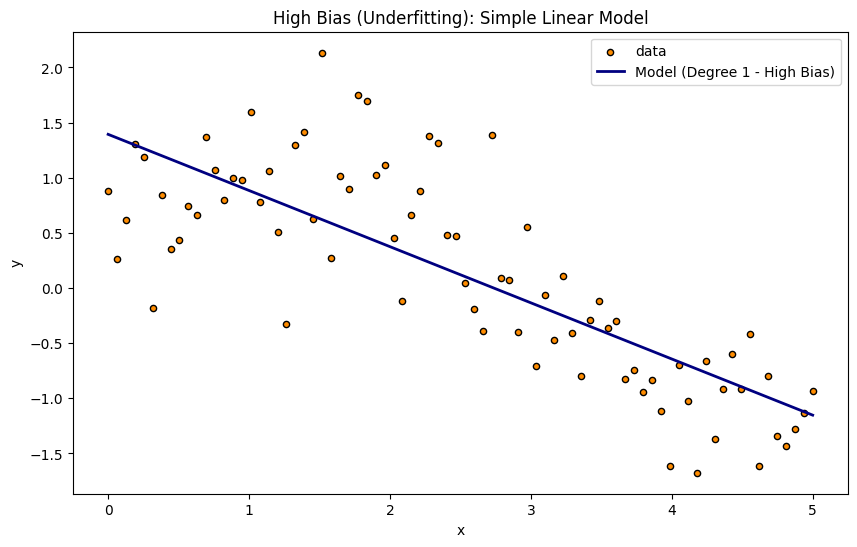

Mean Squared Error for High Bias Model: 0.33


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 5, 80).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.5, X.shape[0])

# --- High Bias (Underfitting) ---
# Use a simple linear model (degree 1 polynomial)

# Create a pipeline with polynomial features (degree 1 for linear) and Linear Regression
degree = 1
model_high_bias = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_high_bias.fit(X, y)

# Make predictions
y_pred_high_bias = model_high_bias.predict(X)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X, y_pred_high_bias, color="navy", linewidth=2, label="Model (Degree 1 - High Bias)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("High Bias (Underfitting): Simple Linear Model")
plt.legend()
plt.show()

print(f"Mean Squared Error for High Bias Model: {mean_squared_error(y, y_pred_high_bias):.2f}")

In the example above, a simple linear model (degree 1 polynomial) is used to fit data that clearly has a non-linear (sine wave) pattern. The model is too rigid and cannot capture the curvature in the data, resulting in a high error. This is a classic case of **underfitting** due to **high bias**.

## 2. Variance and Overfitting

**Variance** refers to the amount that the estimate of the target function will change if different training data were used. Models with high variance are often too complex and sensitive to the specific training data, including noise. This leads to **overfitting**, where the model performs very well on the training data but poorly on new, unseen data because it has learned the noise rather than the underlying pattern.

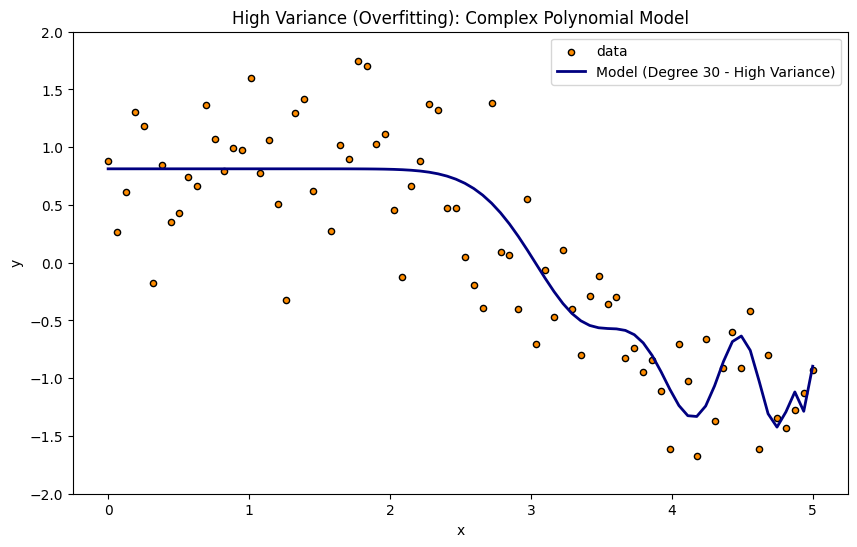

Mean Squared Error for High Variance Model: 0.22


In [2]:
# --- High Variance (Overfitting) ---
# Use a complex polynomial model (e.g., degree 30)

# Create a pipeline with polynomial features (degree 30) and Linear Regression
degree = 30
model_high_variance = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_high_variance.fit(X, y)

# Make predictions
y_pred_high_variance = model_high_variance.predict(X)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X, y_pred_high_variance, color="navy", linewidth=2, label="Model (Degree 30 - High Variance)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("High Variance (Overfitting): Complex Polynomial Model")
plt.legend()
plt.ylim(-2, 2)
plt.show()

print(f"Mean Squared Error for High Variance Model: {mean_squared_error(y, y_pred_high_variance):.2f}")

Here, a very high-degree polynomial (degree 30) is used. Notice how the model curve tries to pass through almost every data point, even the noisy ones. While it might achieve a very low error on the training data, it is likely to perform very poorly on new data because it has captured the random fluctuations (noise) rather than the true underlying pattern. This is a clear case of **overfitting** due to **high variance**.

## 3. The 'Just Right' Model (Low Bias, Low Variance)

Ideally, we want a model that has both low bias and low variance. This means the model is complex enough to capture the true underlying pattern of the data (low bias) but not so complex that it learns the noise (low variance). For our sine wave data, a polynomial of degree 3 or 4 would be more appropriate.

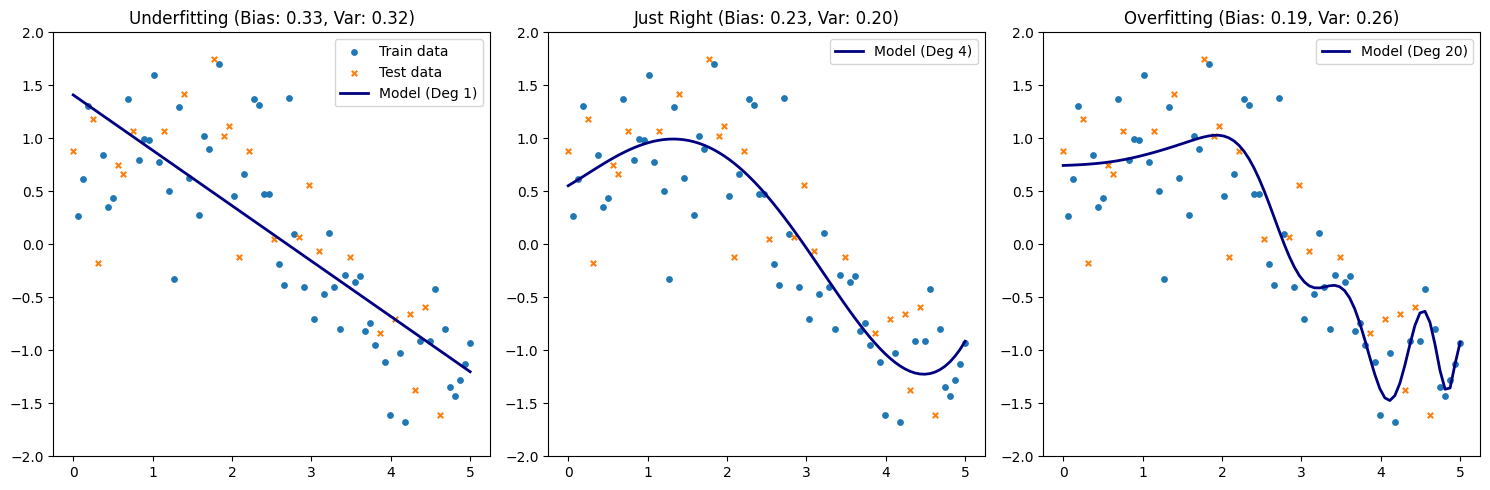

Note: In the titles above, 'Bias' refers to the training error and 'Var' to the testing error. Lower training error and higher testing error indicates overfitting (high variance). Higher training and testing errors indicate underfitting (high bias).


In [3]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(15, 5))

# --- Underfitting (High Bias) ---
plt.subplot(1, 3, 1)
degree_underfit = 1
model_underfit = make_pipeline(PolynomialFeatures(degree_underfit), LinearRegression())
model_underfit.fit(X_train, y_train)
y_pred_underfit_train = model_underfit.predict(X_train)
y_pred_underfit_test = model_underfit.predict(X_test)
plt.scatter(X_train, y_train, s=15, label="Train data")
plt.scatter(X_test, y_test, s=15, label="Test data", marker='x')
plt.plot(X, model_underfit.predict(X), color="navy", linewidth=2, label=f"Model (Deg {degree_underfit})")
plt.title(f"Underfitting (Bias: {mean_squared_error(y_train, y_pred_underfit_train):.2f}, Var: {mean_squared_error(y_test, y_pred_underfit_test):.2f})")
plt.ylim(-2, 2)
plt.legend()

# --- Just Right Model ---
plt.subplot(1, 3, 2)
degree_just_right = 4 # A good balance for sine wave
model_just_right = make_pipeline(PolynomialFeatures(degree_just_right), LinearRegression())
model_just_right.fit(X_train, y_train)
y_pred_just_right_train = model_just_right.predict(X_train)
y_pred_just_right_test = model_just_right.predict(X_test)
plt.scatter(X_train, y_train, s=15)
plt.scatter(X_test, y_test, s=15, marker='x')
plt.plot(X, model_just_right.predict(X), color="navy", linewidth=2, label=f"Model (Deg {degree_just_right})")
plt.title(f"Just Right (Bias: {mean_squared_error(y_train, y_pred_just_right_train):.2f}, Var: {mean_squared_error(y_test, y_pred_just_right_test):.2f})")
plt.ylim(-2, 2)
plt.legend()

# --- Overfitting (High Variance) ---
plt.subplot(1, 3, 3)
degree_overfit = 20 # High degree for overfitting
model_overfit = make_pipeline(PolynomialFeatures(degree_overfit), LinearRegression())
model_overfit.fit(X_train, y_train)
y_pred_overfit_train = model_overfit.predict(X_train)
y_pred_overfit_test = model_overfit.predict(X_test)
plt.scatter(X_train, y_train, s=15)
plt.scatter(X_test, y_test, s=15, marker='x')
plt.plot(X, model_overfit.predict(X), color="navy", linewidth=2, label=f"Model (Deg {degree_overfit})")
plt.title(f"Overfitting (Bias: {mean_squared_error(y_train, y_pred_overfit_train):.2f}, Var: {mean_squared_error(y_test, y_pred_overfit_test):.2f})")
plt.ylim(-2, 2)
plt.legend()

plt.tight_layout()
plt.show()

print("Note: In the titles above, 'Bias' refers to the training error and 'Var' to the testing error. Lower training error and higher testing error indicates overfitting (high variance). Higher training and testing errors indicate underfitting (high bias).")